<a href="https://colab.research.google.com/github/psmaturi/Personalized-Course-Recommendation-System/blob/main/Personalized_Course_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Datasets Loaded Successfully
Enter Username: user005
Enter Password: pass005

👋 Welcome Arjun! | Understanding: Medium

📚 Available Subjects:
1. C
2. C++
3. Java
4. ML
5. CN
6. COA
7. SE
8. Artificial Intelligence
9. Cybersecurity
10. Database Management Systems
11. Operating Systems
12. Big Data
13. Compiler Design

Enter your choice: 12

🎯 Top Recommended Courses for Big Data:



📊 Course Platform Distribution


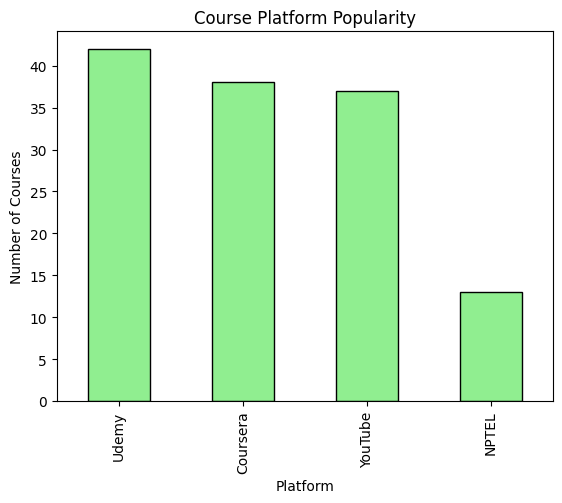

In [ ]:
# =========================
# 📌 Course Recommendation System
# =========================

import pandas as pd
from IPython.display import HTML, display
import matplotlib.pyplot as plt

# -------------------------
# Step 1: Load Data
# -------------------------
students = pd.read_csv("/content/Studentdata.csv")
courses = pd.read_csv("/content/courses_dataset.csv", encoding='latin-1')

# Remove empty rows (fixes 'nan' in subjects list)
courses = courses.dropna()

print("Datasets Loaded Successfully")

# -------------------------
# Step 2: Student Login
# -------------------------
def student_login(username, password):
    user = students[(students["Username"] == username) & (students["Password"] == password)]
    if not user.empty:
        return user.iloc[0]
    else:
        return None

# -------------------------
# Step 3: Choose Subject
# -------------------------
def choose_subject():
    print("\n📚 Available Subjects:")
    subjects = courses["Subject"].unique()
    for i, sub in enumerate(subjects, 1):
        print(f"{i}. {sub}")
    choice = int(input("\nEnter your choice: "))
    return subjects[choice - 1]

# -------------------------
# Step 4: Recommend Courses
# -------------------------
def recommend_courses(student, subject):
    level = student["UnderstandingLevel"]
    iq = student["IQ"]

    subject_courses = courses[courses["Subject"] == subject]

    if level == "High" or iq > 120:
        filtered = subject_courses.head(3)  # Advanced
    elif level == "Medium":
        filtered = subject_courses.iloc[3:6]  # Intermediate
    else:
        filtered = subject_courses.tail(3)  # Beginner

    return filtered

# -------------------------
# Step 5: Pretty Display with Clickable Links
# -------------------------
def display_recommendations(df):
    for i, row in df.iterrows():
        link = f"<a href='{row['Link']}' target='_blank'>{row['Link']}</a>"
        display(HTML(f"""
        <b>Course:</b> {row['CourseName']}<br>
        <b>Platform:</b> {row['Platform']}<br>
        <b>Link:</b> {link}<br><hr>
        """))

# -------------------------
# Step 6: Visualization Dashboard
# -------------------------
def show_dashboard():
    print("\n📊 Course Platform Distribution")
    courses["Platform"].value_counts().plot(kind="bar", color="lightgreen", edgecolor="black")
    plt.title("Course Platform Popularity")
    plt.xlabel("Platform")
    plt.ylabel("Number of Courses")
    plt.show()

# -------------------------
# Step 7: Main Flow
# -------------------------
username = input("Enter Username: ")
password = input("Enter Password: ")

student = student_login(username, password)

if student is not None:
    print(f"\n👋 Welcome {student['Name']}! | Understanding: {student['UnderstandingLevel']}")
    subject = choose_subject()
    print(f"\n🎯 Top Recommended Courses for {subject}:")
    recs = recommend_courses(student, subject)
    display_recommendations(recs)

    # Show analytics
    show_dashboard()
else:
    print("Invalid login credentials!")